#Mining the Relationship Between Music Listening and Mental Health
#CS4403 - Data Mining
#Jeremy Qiao #3753194
#8th April, 2026

#Load this file into a pandas data frame in a Jupyter Notebook

Data Dictionary provided by [@catherinerasgaitis] for the Music and Mental Health Dataset. https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results?resource=download

This dataset contains survey 736 participants exploring the relationship between music listening habits and mental health. It includes music preferences, listening behavior, and self-reported mental health conditions such as anxiety, depression, and insomnia. The dataset is suitable for data analysis, classification, and clustering to identify patterns between music and mental wellness.

## Table of Contents:
•	Participant Information  
•	Music Listening Habits  
•	Mental Health Measures  
•	Additional Attributes  

## Participant Information:

### 1. Age  
Age of the participant

## Music Listening Habits:
What kind of muisc genre they like, how many hours they listen to music per day, what is the BPM of their muisc.

### 1. HoursPerDay  
Average number of hours the participant listens to music per day.

### 2. WhileWorking  
Whether the participant listens to music while working (Yes/No).

### 3. FavGenre  
The participant's favorite music genre (Rock, Pop, Classical, Hip-Hop, etc.).

### 4. Exploratory  
Whether the participant actively explores new music (Yes/No).

### 5. ForeignLanguages  
Whether the participant listens to music in foreign languages (Yes/No).

### 6. BPM  
Preferred beats per minute of music.

## Mental Health Measures:

### 1. Anxiety  
Self-reported anxiety level (scale 0-10).

### 2. Depression  
Self-reported depression level (scale 0-10).

### 3. Insomnia  
Self-reported insomnia level (scale 0-10).

### 4. OCD  
Self-reported OCD level (scale  0-10).



## MusicEffects:
Participant's perception of how music affects their mental health:

•	Improve  
•	No Effect  
•	Worsen  

Evidence of the impact of music listening habits on mental wellness can be found in this dataset. Using a combination of behavioural and psychological data makes it easier to find trends and build models that predict music's influence on anxiety, depression, insomnia.

In [52]:
#data handling
import pandas as pd
import numpy as np

#visualization
import seaborn as sns
import matplotlib.pyplot as plt

#LLM_ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC, SVR #SVM


#easy download
import gdown

#Download the dataset  and load the data

In [53]:

#load dataset
file_id = '1JG2XnjWLd6J1XI_feIwfUq_sCwbxiwj_'
url = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url, 'MusicMental.csv', quiet=False)

df = pd.read_csv('MusicMental.csv')

df.head(10)

Downloading...
From: https://drive.google.com/uc?id=1JG2XnjWLd6J1XI_feIwfUq_sCwbxiwj_
To: /content/MusicMental.csv
100%|██████████| 173k/173k [00:00<00:00, 47.3MB/s]


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,...,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.0,Yes,No,No,Rock,No,No,...,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.0,Yes,No,No,R&B,Yes,Yes,...,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.


Helping Jake saves his time for downloading data.

#Full data check to understand the dataset before modeling.

In [54]:
#preview
print("First 5 rows:")
display(df.head())

#column names
print("\nColumn names:")
print(df.columns.tolist())

#data quality
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_index()

print("\nSummary table:")
display(summary)

#check categorical columns (i will remove some of them later)
key_categorical_cols = [
    "Primary streaming service",
    "While working",
    "Instrumentalist",
    "Composer",
    "Fav genre",
    "Exploratory",
    "Foreign languages",
    "Music effects"
]

for col in key_categorical_cols:
    if col in df.columns:
        print(f"\nValue counts: {col}")
        print(df[col].value_counts(dropna=False))
print("\nNumeric summary statistics:")
display(df.describe())

#duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

#important numeric columns
important_numeric_cols = [
    "Age",
    "Hours per day",
    "BPM",
    "Anxiety",
    "Depression",
    "Insomnia",
    "OCD"
]

for col in important_numeric_cols:
    if col in df.columns:
        print(f"\nColumn: {col}")
        print("Min:", df[col].min())
        print("Max:", df[col].max())

First 5 rows:


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.



Column names:
['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']

Summary table:


,dtype,non_null,missing,missing_%,n_unique
Age,float64,735,1,0.14,61
Anxiety,float64,736,0,0.00,12
BPM,float64,629,107,14.54,135
Composer,object,735,1,0.14,2
Depression,float64,736,0,0.00,12
Exploratory,object,736,0,0.00,2
Fav genre,object,736,0,0.00,16
Foreign languages,object,732,4,0.54,2
Frequency [Classical],object,736,0,0.00,4
Frequency [Country],object,736,0,0.00,4



Value counts: Primary streaming service
Primary streaming service
Spotify                              458
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50
Pandora                               11
NaN                                    1
Name: count, dtype: int64

Value counts: While working
While working
Yes    579
No     154
NaN      3
Name: count, dtype: int64

Value counts: Instrumentalist
Instrumentalist
No     497
Yes    235
NaN      4
Name: count, dtype: int64

Value counts: Composer
Composer
No     609
Yes    126
NaN      1
Name: count, dtype: int64

Value counts: Fav genre
Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
Hip hop              35
R&B                  35
Folk                 30
K pop                26
Country              25
Rap                  

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000



Duplicate rows: 0

Column: Age
Min: 10.0
Max: 89.0

Column: Hours per day
Min: 0.0
Max: 24.0

Column: BPM
Min: 0.0
Max: 999999999.0

Column: Anxiety
Min: 0.0
Max: 10.0

Column: Depression
Min: 0.0
Max: 10.0

Column: Insomnia
Min: 0.0
Max: 10.0

Column: OCD
Min: 0.0
Max: 10.0


The dataset has 736 rows and 33 columns.
Some column has missing values (especially BPM: 14% missing).
Most people use Spotify and listen to music while working.
The most popular genre is Rock, followed by Pop and Metal
Most users say music improves their mood.


No duplicate rows found, some values look unrealistic, especially BPM (very large numbers, there is a 999999 influence the whole vaule)
Age ranges from 10 to 89, which is reasonable.
Mental health scores (Anxiety) are between 0 - 10.

#Creates a histogram plot to show how ages are distributed in the dataset

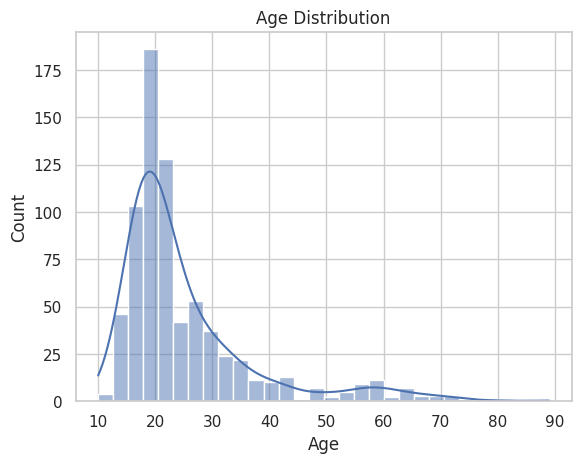

In [55]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Graph shows that most people in my dataset are young, mainly around 18 to 25, with a peak near age 20. There are fewer older people, but some still exist up to higher ages.

#Creates a histogram to show how many hours per day people listen to music and how those values are distributed.

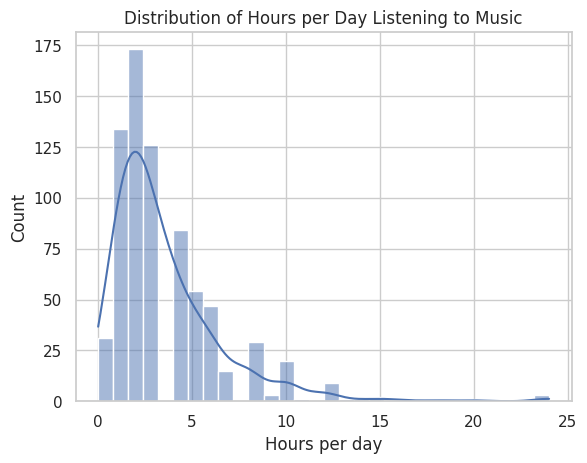

In [56]:
sns.histplot(df["Hours per day"], bins=30, kde=True)
plt.title("Distribution of Hours per Day Listening to Music")
plt.xlabel("Hours per day")
plt.ylabel("Count")
plt.show()

This graph shows that most people listen to music about 1 to 4 hours per day, with a peak around 2 - 3 hours. Only a few people listen for a very long time like over 10 hours.

#Creates a pie chart to show the percentage distribution of people's favorite music genres.

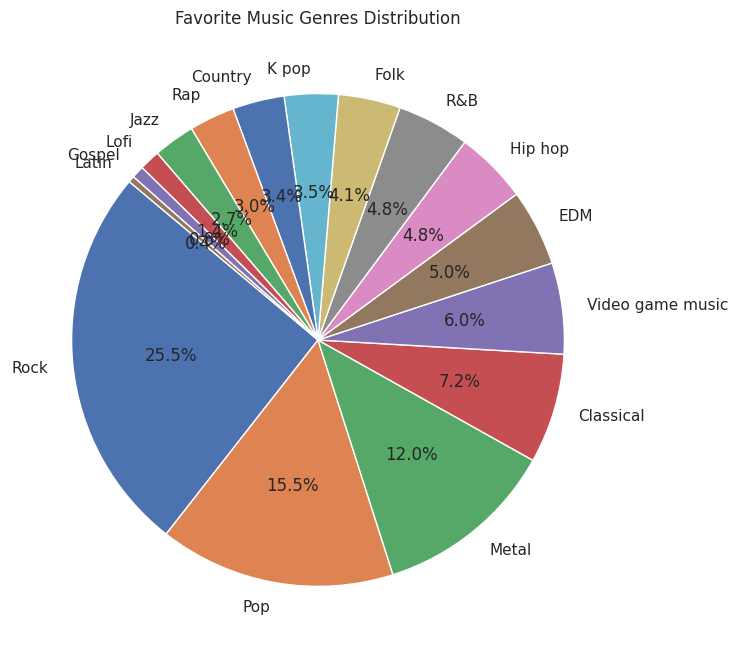

In [57]:
#count each genre
genre_counts = df["Fav genre"].value_counts()

#plot
plt.figure(figsize=(8,8))
plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Favorite Music Genres Distribution")
plt.show()

This chart shows that Rock is the most popular genre. Pop and Metal are also quite popular, but smaller than Rock.

Genres like Classical, Video game music, EDM, and Hip hop are in the middle, not too big but still common.

#Creates a bar chart showing how many people are instrumentalists vs not instrumentalists in the dataset.

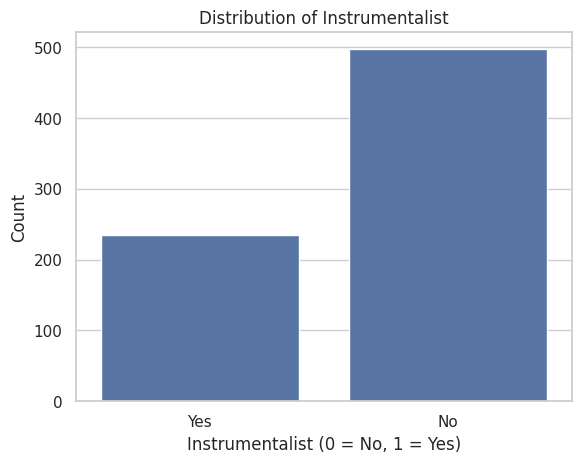

In [58]:
sns.countplot(x="Instrumentalist", data=df)

plt.title("Distribution of Instrumentalist")
plt.xlabel("Instrumentalist (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

This graph shows that most people are not instrumentalists, because the “No” bar is much higher than “Yes”.

#Creates a bar chart showing how many people are composers vs not composers in the dataset.

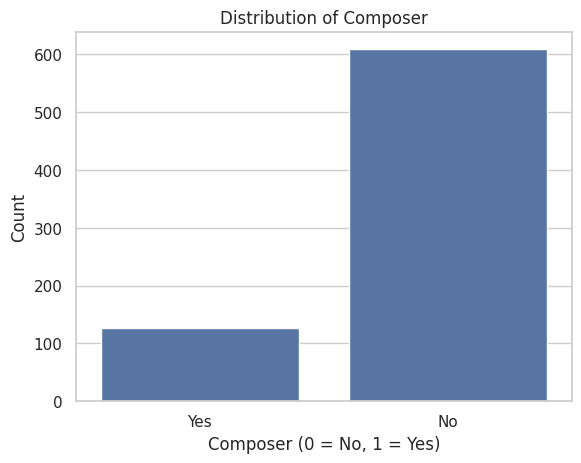

In [59]:
sns.countplot(x="Composer", data=df)

plt.title("Distribution of Composer")
plt.xlabel("Composer (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

This graph shows that most people are not composer, because the “No” bar is much higher than “Yes”.

#Cleaning the dataset (filling missing values, removing unrealistic BPM values, dropping unnecessary columns.)

In [60]:
#fill missing values in Age
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

#fill missing values in BPM
if "BPM" in df.columns:
    df["BPM"] = df["BPM"].fillna(df["BPM"].median())

#remove outliars of  BPM values
if "BPM" in df.columns:
    df = df[(df["BPM"] > 40) & (df["BPM"] < 250)]

#fill missing Yes/No values
for col in ["Composer", "Instrumentalist"]:
    if col in df.columns:
        df[col] = df[col].fillna("No")

#using mode to fill missing categorical values
for col in ["Music effects", "Fav genre", "Primary streaming service"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

#drop unnecessary columns
cols_to_drop = ["Primary streaming service", "Permissions", "Timestamp", "Fav genre"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(df.columns)
df.head()

Index(['Age', 'Hours per day', 'While working', 'Instrumentalist', 'Composer',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects'],
      dtype='object')


,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],...,Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects
0,18.0,3.0,Yes,Yes,Yes,Yes,Yes,156.0,Rarely,Never,...,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,Improve
1,63.0,1.5,Yes,No,No,Yes,No,119.0,Sometimes,Never,...,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,Improve
2,18.0,4.0,No,No,No,No,Yes,132.0,Never,Never,...,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect
3,61.0,2.5,Yes,No,Yes,Yes,Yes,84.0,Sometimes,Never,...,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve
4,18.0,4.0,Yes,No,No,Yes,No,107.0,Never,Never,...,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve


Filling missing values in Age and BPM using the median (keep the data balanced.) I remove strange BPM values that are too low or too high (liar).

Handling missing Yes/No values by filling them with “No”, and for other categories you use the most common value. I dropped some columns like streaming service and favorite genre, removing things I don't need for later analysis.


#Handling missing values and converting all categorical data into numerical format (encoding).

In [61]:
#handle missing values and outliers
for col in ["Music effects", "While working", "Exploratory", "Foreign languages"]:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])#follow the most frequent category.


#standardize Music effects values
if "Music effects" in df.columns:
    df["Music effects"] = df["Music effects"].replace({
        "Improve": "Improve",
        "Improved": "Improve",
        "No effect": "No effect",
        "Worsen": "Worsen",
        "Worse": "Worsen"
    })

    print("\nMusic effects before encoding:")
    print(df["Music effects"].value_counts(dropna=False))

# Check binary columns before encoding
binary_cols = [
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages"
]

print("\nBefore binary encoding:")
for col in binary_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))

# Binary encoding
binary_map = {
    "Yes": 1, "No": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0,
    "True": 1, "False": 0,
    True: 1, False: 0
}

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace(binary_map)

# Ordinal encoding for frequency columns
frequency_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Very frequently": 4,
    "Very often": 5
}

freq_cols = [col for col in df.columns if col.startswith("Frequency [")]

for col in freq_cols:
    df[col] = df[col].replace(frequency_map)

# One-hot encoding
if "Music effects" in df.columns:
    df = pd.get_dummies(df, columns=["Music effects"], drop_first=False)

# Convert boolean columns to 0/1
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# Final check
print("\nAfter encoding:")
for col in binary_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))

print("\nColumns related to Music effects:")
print([col for col in df.columns if "Music effects" in col])

print("\nRemaining object columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataFrame info:")
df.info()

df.head(10)


Music effects before encoding:
Music effects
Improve      543
No effect    167
Worsen        17
Name: count, dtype: int64

Before binary encoding:

While working
While working
Yes    576
No     151
Name: count, dtype: int64

Instrumentalist
Instrumentalist
No     495
Yes    232
Name: count, dtype: int64

Composer
Composer
No     602
Yes    125
Name: count, dtype: int64

Exploratory
Exploratory
Yes    518
No     209
Name: count, dtype: int64

Foreign languages
Foreign languages
Yes    403
No     324
Name: count, dtype: int64

After encoding:

While working
While working
1    576
0    151
Name: count, dtype: int64

Instrumentalist
Instrumentalist
0    495
1    232
Name: count, dtype: int64

Composer
Composer
0    602
1    125
Name: count, dtype: int64

Exploratory
Exploratory
1    518
0    209
Name: count, dtype: int64

Foreign languages
Foreign languages
1    403
0    324
Name: count, dtype: int64

Columns related to Music effects:
['Music effects_Improve', 'Music effects_No effect', '

/tmp/ipykernel_5610/2329049566.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(binary_map)
/tmp/ipykernel_5610/2329049566.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(frequency_map)


,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],...,Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects_Improve,Music effects_No effect,Music effects_Worsen
0,18.0,3.0,1,1,1,1,1,156.0,1,0,...,4,0,2,3.0,0.0,1.0,0.0,1,0,0
1,63.0,1.5,1,0,0,1,0,119.0,2,0,...,1,4,1,7.0,2.0,2.0,1.0,1,0,0
2,18.0,4.0,0,0,0,0,1,132.0,0,0,...,1,1,4,7.0,7.0,10.0,2.0,0,1,0
3,61.0,2.5,1,0,1,1,1,84.0,2,0,...,0,0,0,9.0,7.0,3.0,3.0,1,0,0
4,18.0,4.0,1,0,0,1,0,107.0,0,0,...,4,0,1,7.0,2.0,5.0,9.0,1,0,0
5,18.0,5.0,1,1,1,1,1,86.0,1,2,...,4,4,0,8.0,8.0,7.0,7.0,1,0,0
6,18.0,3.0,1,1,0,1,1,66.0,2,0,...,0,0,2,4.0,8.0,6.0,0.0,1,0,0
7,21.0,1.0,1,0,0,1,1,95.0,0,0,...,1,0,1,5.0,3.0,5.0,3.0,1,0,0
8,19.0,6.0,1,0,0,0,0,94.0,0,4,...,0,4,0,2.0,0.0,0.0,0.0,1,0,0
9,18.0,1.0,1,0,0,1,1,155.0,1,1,...,1,2,2,2.0,2.0,5.0,1.0,1,0,0


I remove useless columns, fix missing values. Then I change Yes/No and frequency into numbers, and convert categories into columns. The final data has no missing values and is ready to use for models.

For frequency: "Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Very frequently": 4, "Very often": 5

#Download the clean dataset

In [62]:
df.to_csv("clean_music_data.csv", index=False)

#Remove frequency then creating a correlation heatmap.

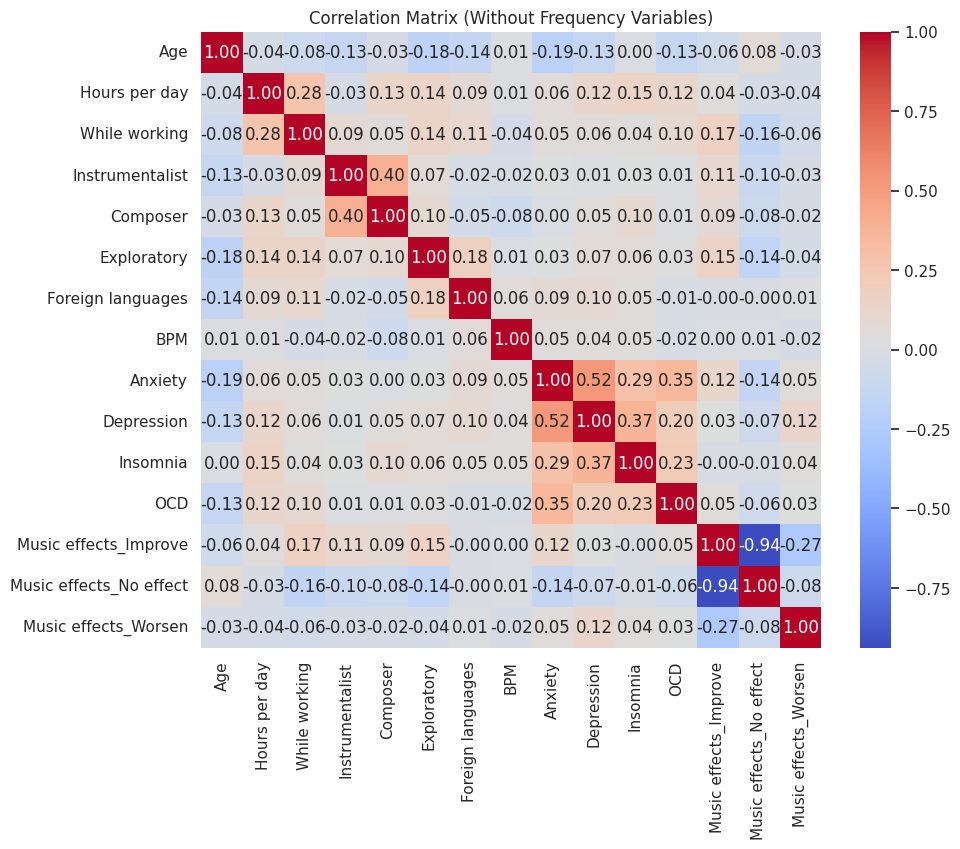

In [63]:
#remove frequency columns (make heatmap messy)
df_no_freq = df.drop(columns=[col for col in df.columns if "Frequency" in col])

#correlation matrix
corr = df_no_freq.corr(numeric_only=True)

#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix (Without Frequency Variables)")
plt.show()

#Based on Music Listening Features Classification Analysis of Mental Health Conditions

In [65]:
targets = ["Depression", "Anxiety", "Insomnia", "OCD"]
results = []
for target in targets:

    print(f"\n===== Evaluating {target} =====")

    #create binary classification (Low vs High)
    # Threshold = median

    threshold = df[target].median()
    df[f"{target}_binary"] = (df[target] >= threshold).astype(int)

    #prepare features and labels
    X = df.drop(columns=targets + [f"{t}_binary" for t in targets if f"{t}_binary" in df.columns])
    y = df[f"{target}_binary"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )


    # Scaling (important for consistency)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # Train model (Random Forest)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)


    #Predictions

    y_pred = model.predict(X_test)

    #evaluation metrics

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")

    # Save results
    results.append([target, acc, prec, rec, f1])

#table
results_df = pd.DataFrame(results, columns=["Target", "Accuracy", "Precision", "Recall", "F1"])

print("\n===== Summary Table =====")
print(results_df)


===== Evaluating Depression =====
Accuracy:  0.623
Precision: 0.636
Recall:    0.709
F1-score:  0.671

===== Evaluating Anxiety =====
Accuracy:  0.610
Precision: 0.648
Recall:    0.773
F1-score:  0.705

===== Evaluating Insomnia =====
Accuracy:  0.589
Precision: 0.624
Recall:    0.699
F1-score:  0.659

===== Evaluating OCD =====
Accuracy:  0.486
Precision: 0.518
Recall:    0.564
F1-score:  0.540

===== Summary Table =====
       Target  Accuracy  Precision    Recall        F1
0  Depression  0.623288   0.636364  0.708861  0.670659
1     Anxiety  0.609589   0.647619  0.772727  0.704663
2    Insomnia  0.589041   0.623656  0.698795  0.659091
3         OCD  0.486301   0.517647  0.564103  0.539877


This study evaluates the relationship between music-related features and four mental health variables: Depression, Anxiety, Insomnia, and OCD.

Each variable is converted into a binary classification problem (Low vs High) using the median as the threshold. A Random Forest classifier is used for all tasks.

#Quantile-Based Classification of mental health Levels

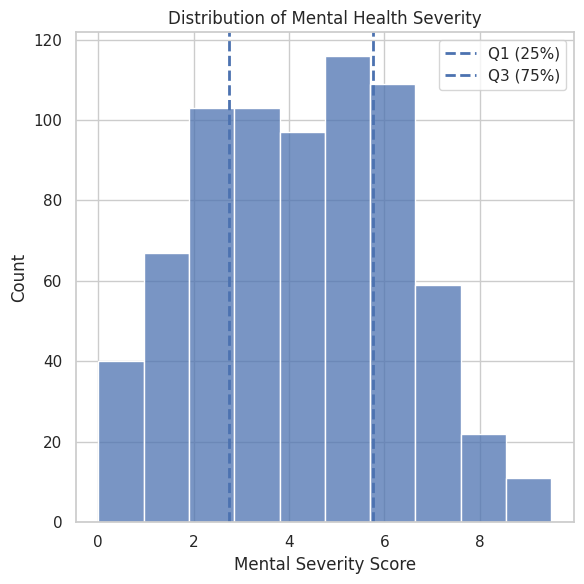

In [82]:
# combine
df["Mental_Severity_All"] = (
    df["Depression"] +
    df["Anxiety"] +
    df["Insomnia"] +
    df["OCD"]
) / 4

# compute quantiles
q1 = df["Mental_Severity_All"].quantile(0.25)
q3 = df["Mental_Severity_All"].quantile(0.75)

# plot FIRST
plt.figure(figsize=(6, 6))
sns.histplot(df["Mental_Severity_All"], bins=10)

# THEN add lines
plt.axvline(x=q1, linestyle="--", linewidth=2, label="Q1 (25%)")
plt.axvline(x=q3, linestyle="--", linewidth=2, label="Q3 (75%)")

plt.title("Distribution of Mental Health Severity")
plt.xlabel("Mental Severity Score")
plt.ylabel("Count")

plt.legend()
plt.tight_layout()
plt.show()

#Training models to predict mental health level.

===== Logistic Regression =====
Accuracy: 0.3904109589041096
              precision    recall  f1-score   support

         Low       0.34      0.26      0.30        42
      Medium       0.44      0.59      0.50        64
        High       0.30      0.20      0.24        40

    accuracy                           0.39       146
   macro avg       0.36      0.35      0.35       146
weighted avg       0.37      0.39      0.37       146

===== SVM =====
Accuracy: 0.4520547945205479
              precision    recall  f1-score   support

         Low       0.50      0.21      0.30        42
      Medium       0.46      0.80      0.59        64
        High       0.33      0.15      0.21        40

    accuracy                           0.45       146
   macro avg       0.43      0.39      0.36       146
weighted avg       0.44      0.45      0.40       146

===== Random Forest =====
Accuracy: 0.4452054794520548
              precision    recall  f1-score   support

         Low       0.4

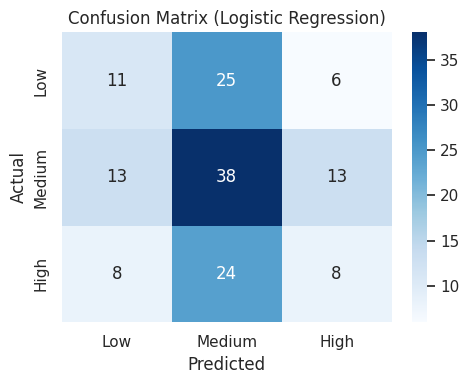

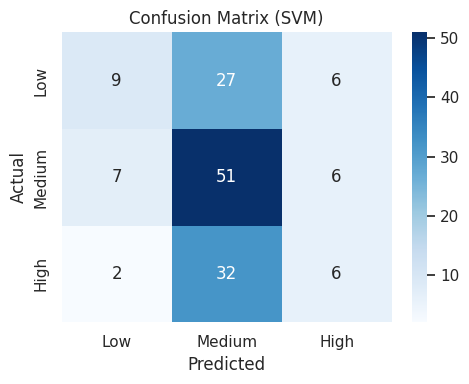

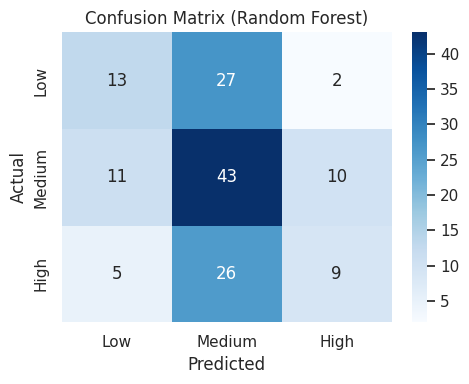

===== Top 15 Important Features =====
Age                             0.105161
BPM                             0.093860
Hours per day                   0.073550
Frequency [Metal]               0.044874
Frequency [Video game music]    0.044406
Frequency [Lofi]                0.043935
Frequency [R&B]                 0.041510
Frequency [Rap]                 0.041404
Frequency [EDM]                 0.040962
Frequency [Folk]                0.040062
Frequency [Rock]                0.039698
Frequency [Pop]                 0.039212
Frequency [Classical]           0.038410
Frequency [Hip hop]             0.036225
Frequency [Jazz]                0.035348
dtype: float64


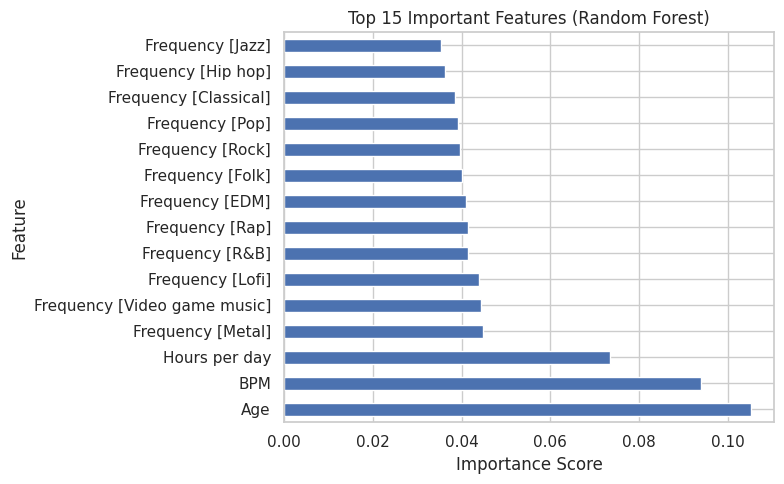

In [84]:
# =========================
# Create combined mental health score
# =========================
df["Mental_Severity_All"] = (
    df["Depression"] +
    df["Anxiety"] +
    df["Insomnia"] +
    df["OCD"]
) / 4


# =========================
# Quantile-based classification
# 0 = Low, 1 = Medium, 2 = High
# =========================
q1 = df["Mental_Severity_All"].quantile(0.25)
q3 = df["Mental_Severity_All"].quantile(0.75)

def classify_mental_level(x):
    if x <= q1:
        return 0
    elif x >= q3:
        return 2
    else:
        return 1

df["Mental_Health_Level"] = df["Mental_Severity_All"].apply(classify_mental_level)


# =========================
# Define features
# Exclude target-related columns to avoid data leakage
# Also exclude Age if you want ONLY music-related features
# =========================
columns_to_drop = [
    "Depression",
    "Anxiety",
    "Insomnia",
    "OCD",
    "Mental_Severity_All",
    "Mental_Health_Level"
]

X = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
y = df["Mental_Health_Level"]


# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================
# Scale data for Logistic Regression and SVM
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# Logistic Regression
# =========================
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Low", "Medium", "High"]))


# =========================
# SVM
# =========================
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("===== SVM =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=["Low", "Medium", "High"]))


# =========================
# Random Forest
# =========================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["Low", "Medium", "High"]))


# =========================
# Confusion Matrix - Logistic Regression
# =========================
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================
# Confusion Matrix - SVM
# =========================
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================
# Confusion Matrix - Random Forest
# =========================
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================
# Feature Importance - Random Forest
# =========================
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("===== Top 15 Important Features =====")
print(feature_importance.head(15))


# Optional: plot top 15 important features
plt.figure(figsize=(8, 5))
feature_importance.head(15).plot(kind="barh")
plt.title("Top 15 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The classification results show relatively low performance across all models, with accuracy ranging from 0.41 to 0.45. This indicates that music-related features have limited predictive power for mental health levels.

All models tend to predict the “Medium” class more frequently, as shown by its higher recall compared to “Low” and “High” classes. This suggests that the models struggle to distinguish extreme mental health conditions.

Overall, these results support the conclusion that music listening behavior alone is not a strong predictor of mental health status.

#Which features are associated with mental health level?

Shape: (727, 33)
    Age  Hours per day  While working  Instrumentalist  Composer  Exploratory  \
0  18.0            3.0              1                1         1            1   
1  63.0            1.5              1                0         0            1   
2  18.0            4.0              0                0         0            0   
3  61.0            2.5              1                0         1            1   
4  18.0            4.0              1                0         0            1   

   Foreign languages    BPM  Frequency [Classical]  Frequency [Country]  ...  \
0                  1  156.0                      1                    0  ...   
1                  0  119.0                      2                    0  ...   
2                  1  132.0                      0                    0  ...   
3                  1   84.0                      2                    0  ...   
4                  0  107.0                      0                    0  ...   

   Frequency [V

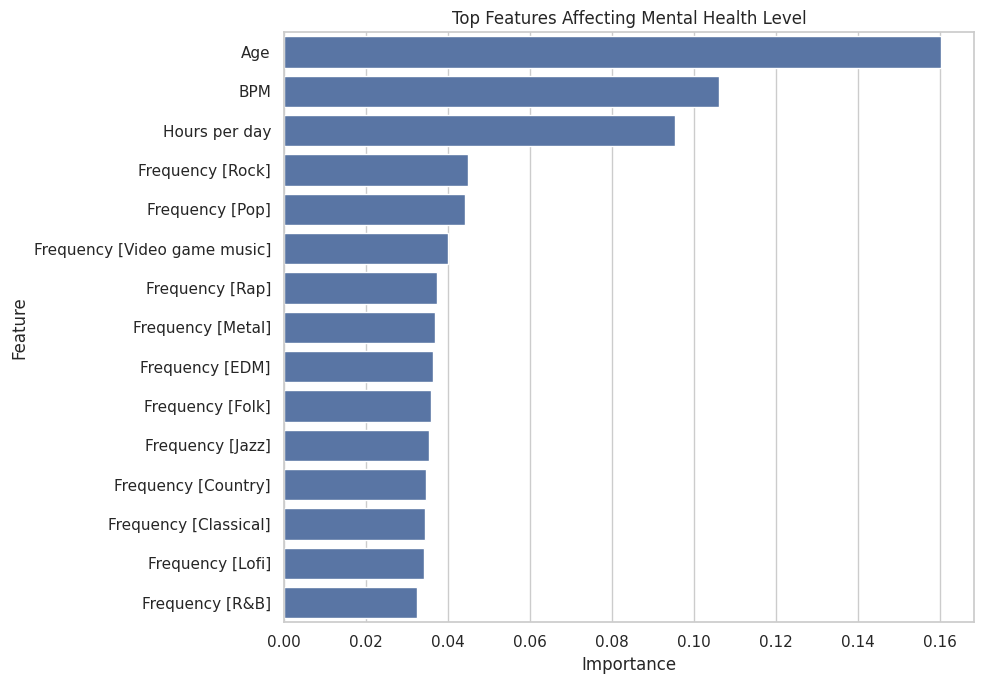

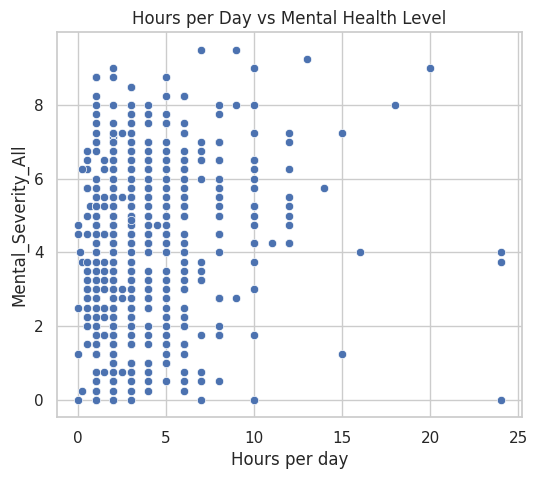

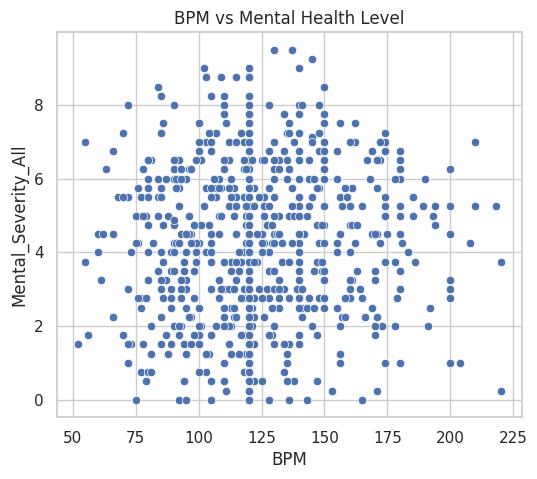

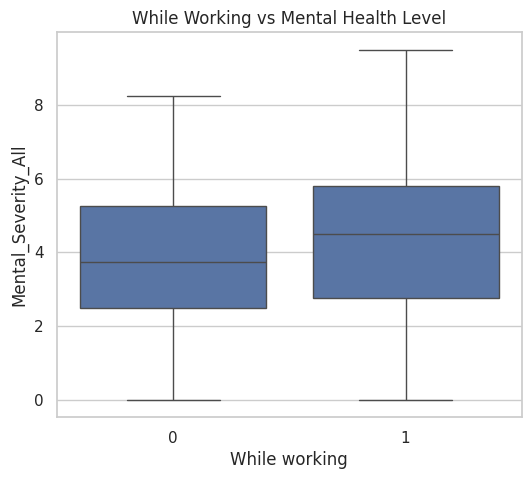

In [78]:
sns.set_theme(style="whitegrid")
print("Shape:", df.shape)
print(df.head())


y = df["Mental_Severity_All"]


# =========================
# Define features
# =========================
music_features = [
    "Age",
    "Hours per day",
    "BPM",
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages"
]

music_features = [col for col in music_features if col in df.columns]

# Frequency / Genre / Effects
frequency_cols = [col for col in df.columns if col.startswith("Frequency")]
genre_cols = [col for col in df.columns if col.startswith("Fav genre_")]
effect_cols = [col for col in df.columns if col.startswith("Music effects_")]

features = music_features + frequency_cols + genre_cols + effect_cols
features = [col for col in features if col in df.columns]

X = df[features]

print("\nNumber of features:", len(features))


# =========================
# Check for leakage
# =========================
for col in ["Depression", "Anxiety", "Insomnia", "OCD", "Mental_Severity_All"]:
    if col in X.columns:
        print("ERROR: Leakage column found:", col)


# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================
# Train model
# =========================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


# =========================
# Prediction
# =========================
y_pred = model.predict(X_test)


# =========================
# Evaluation
# =========================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== Mental Health Regression Results =====")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))


# =========================
# Feature Importance
# =========================
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Features Affecting Mental Health:")
print(importance_df.head(15))


plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top Features Affecting Mental Health Level")
plt.tight_layout()
plt.show()


# =========================
# Visualization
# =========================

# Hours per day vs Mental Health
if "Hours per day" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x="Hours per day", y="Mental_Severity_All", data=df)
    plt.title("Hours per Day vs Mental Health Level")
    plt.show()

# BPM vs Mental Health
if "BPM" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x="BPM", y="Mental_Severity_All", data=df)
    plt.title("BPM vs Mental Health Level")
    plt.show()

# While working vs Mental Health
if "While working" in df.columns:
    plt.figure(figsize=(6,5))
    sns.boxplot(x="While working", y="Mental_Severity_All", data=df)
    plt.title("While Working vs Mental Health Level")
    plt.show()

The model used in this research initially included Age together with the music-related features. However, Age is not a music-related variable, so including it may introduce a confounding effect when analyzing the relationship between music listening behavior and mental health.

The main purpose of this study is to examine the relationship between music-related features and overall mental health level. For this reason, Age was removed in the revised model. By removing Age, the analysis becomes more focused on music-related features and is less affected by demographic factors.

As a result, the revised model better represents the research question and provides a clearer understanding of the relationship between music listening behavior and mental health.

#Which music related features are associated with mental health level?

Shape: (727, 31)
    Age  Hours per day  While working  Instrumentalist  Composer  Exploratory  \
0  18.0            3.0              1                1         1            1   
1  63.0            1.5              1                0         0            1   
2  18.0            4.0              0                0         0            0   
3  61.0            2.5              1                0         1            1   
4  18.0            4.0              1                0         0            1   

   Foreign languages    BPM  Frequency [Classical]  Frequency [Country]  ...  \
0                  1  156.0                      1                    0  ...   
1                  0  119.0                      2                    0  ...   
2                  1  132.0                      0                    0  ...   
3                  1   84.0                      2                    0  ...   
4                  0  107.0                      0                    0  ...   

   Frequency [R

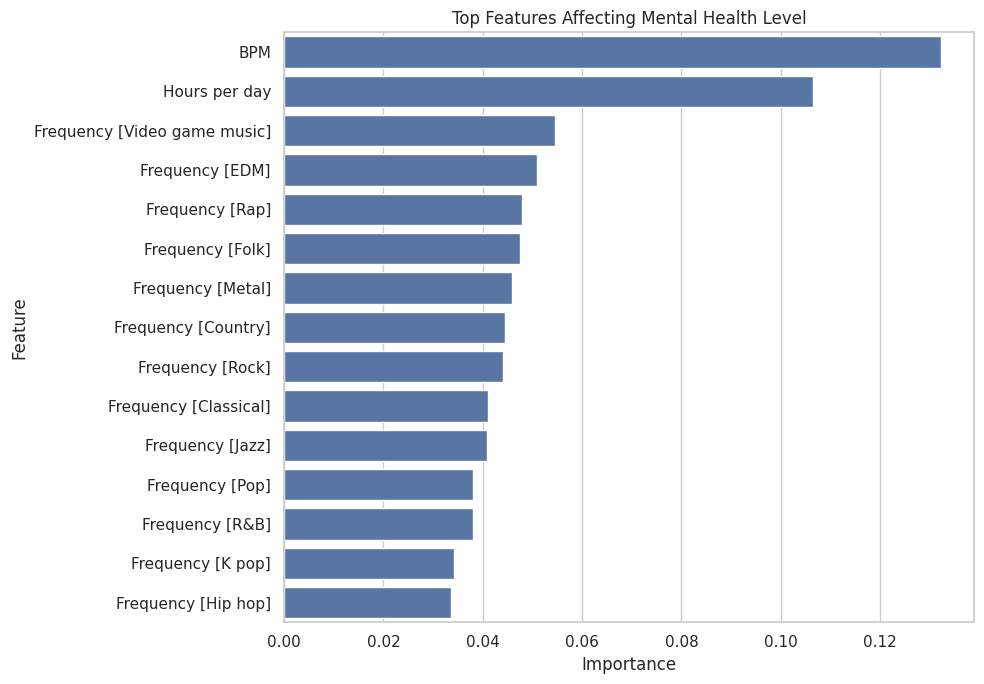

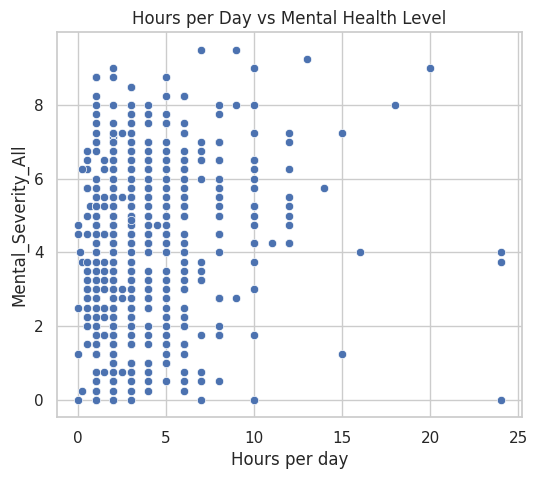

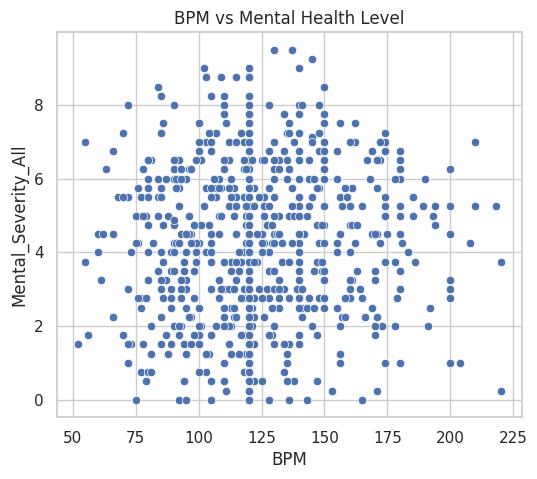

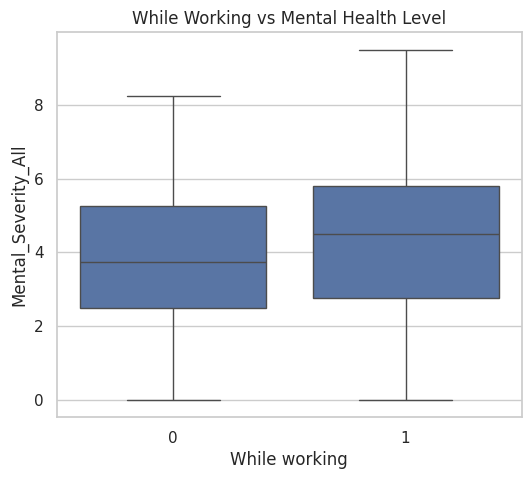

In [79]:
df = pd.read_csv("clean_music_data.csv")

print("Shape:", df.shape)
print(df.head())
df["Mental_Severity_All"] = (
    df["Depression"] +
    df["Anxiety"] +
    df["Insomnia"] +
    df["OCD"]
) / 4
# Regression target
y = df["Mental_Severity_All"]


# =========================
# Define features
# =========================
music_features = [
    "Age",
    "Hours per day",
    "BPM",
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages"
]

music_features = [col for col in music_features if col in df.columns]

# Frequency / Genre / Effects
frequency_cols = [col for col in df.columns if col.startswith("Frequency")]
genre_cols = [col for col in df.columns if col.startswith("Fav genre_")]
effect_cols = [col for col in df.columns if col.startswith("Music effects_")]

features = music_features + frequency_cols + genre_cols + effect_cols

# Remove Age
features = [col for col in features if col != "Age"]

X = df[features]

print("\nNumber of features:", len(features))


# =========================
# Check for leakage
# =========================
for col in ["Depression", "Anxiety", "Insomnia", "OCD", "Mental_Severity_All"]:
    if col in X.columns:
        print("ERROR: Leakage column found:", col)


#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


#train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== Regression Results for Mental Health Level =====")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))


# =========================
# Feature Importance
# =========================
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Features Affecting Mental Health Level:")
print(importance_df.head(15))


plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top Features Affecting Mental Health Level")
plt.tight_layout()
plt.show()


# Hours per day vs Mental Health Level
if "Hours per day" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x="Hours per day", y="Mental_Severity_All", data=df)
    plt.title("Hours per Day vs Mental Health Level")
    plt.show()

# BPM vs Mental Health Level
if "BPM" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x="BPM", y="Mental_Severity_All", data=df)
    plt.title("BPM vs Mental Health Level")
    plt.show()

# While working vs Mental Health Level
if "While working" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(x="While working", y="Mental_Severity_All", data=df)
    plt.title("While Working vs Mental Health Level")
    plt.show()

Removing Age from the analysis only explains a very small part of the variation in overall mental health level (R² ≈ 0.013). This means that other factors are also important in explaining a person's mental health. Many variables need to be considered when evaluating overall mental health.

Some music-related variables show a weak relationship with mental health, such as how many hours a person listens to music and certain genres (such as Rock, Metal, and Rap). This suggests that music habits may reflect some emotional patterns. However, music alone is not enough to accurately predict a person's overall mental health level.

#Relationship Between Hours of Music Listening and Mental Health

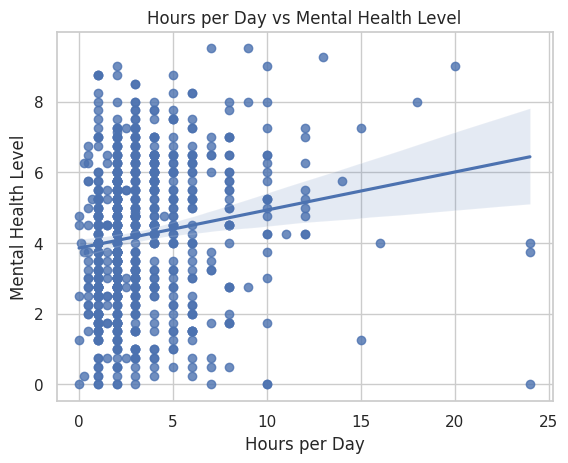

In [72]:
sns.regplot(x="Hours per day", y="Mental_Severity_All", data=df)
plt.title("Hours per Day vs Mental Health Level")
plt.xlabel("Hours per Day")
plt.ylabel("Mental Health Level")
plt.show()

#Compare 4 Regression Models for Mental Health
# Models:
# 1. Linear Regression
# 2. KNN Regressor
# 3. SVR
# 4. Random Forest Regressor
# 5. Gradient Boosting Regressor


Shape: (727, 32)

First 5 rows:
    Age  Hours per day  While working  Instrumentalist  Composer  Exploratory  \
0  18.0            3.0              1                1         1            1   
1  63.0            1.5              1                0         0            1   
2  18.0            4.0              0                0         0            0   
3  61.0            2.5              1                0         1            1   
4  18.0            4.0              1                0         0            1   

   Foreign languages    BPM  Frequency [Classical]  Frequency [Country]  ...  \
0                  1  156.0                      1                    0  ...   
1                  0  119.0                      2                    0  ...   
2                  1  132.0                      0                    0  ...   
3                  1   84.0                      2                    0  ...   
4                  0  107.0                      0                    0  ...   



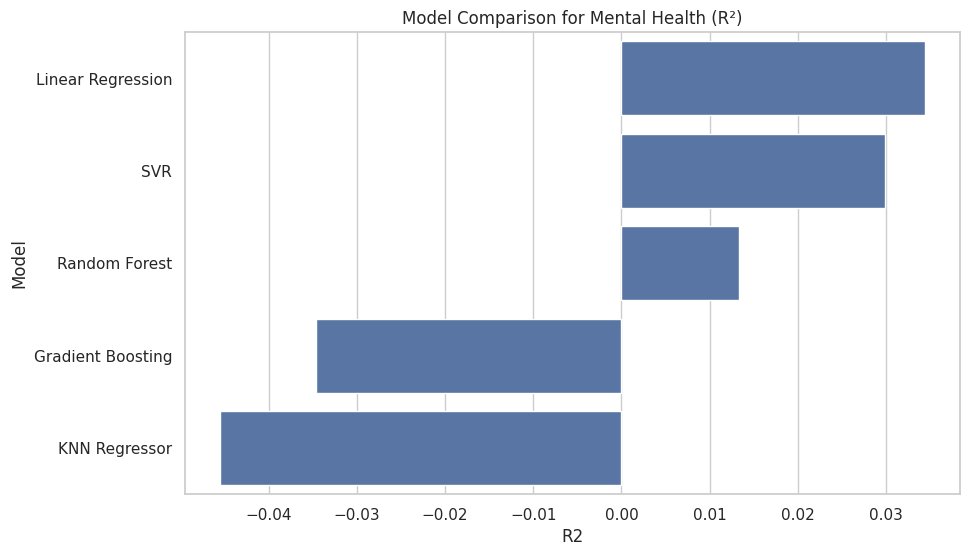

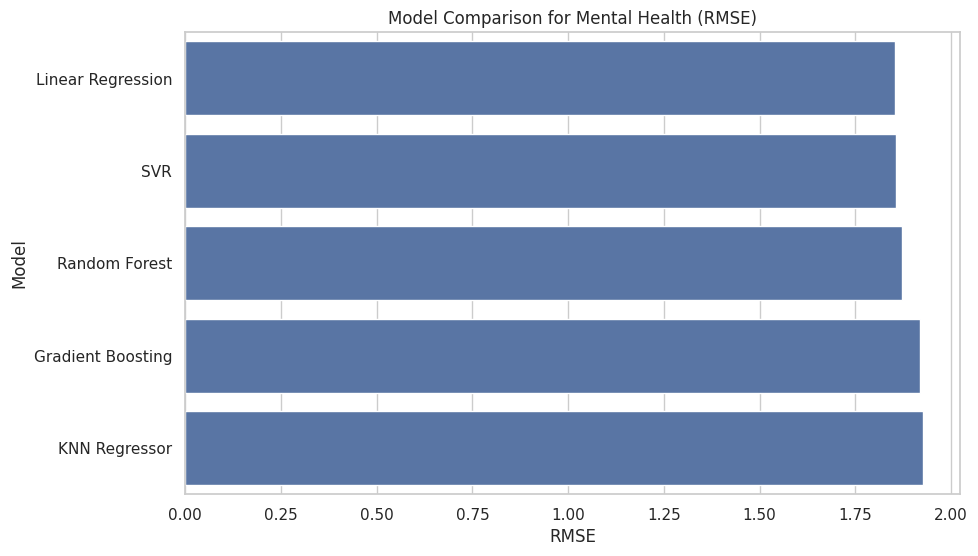

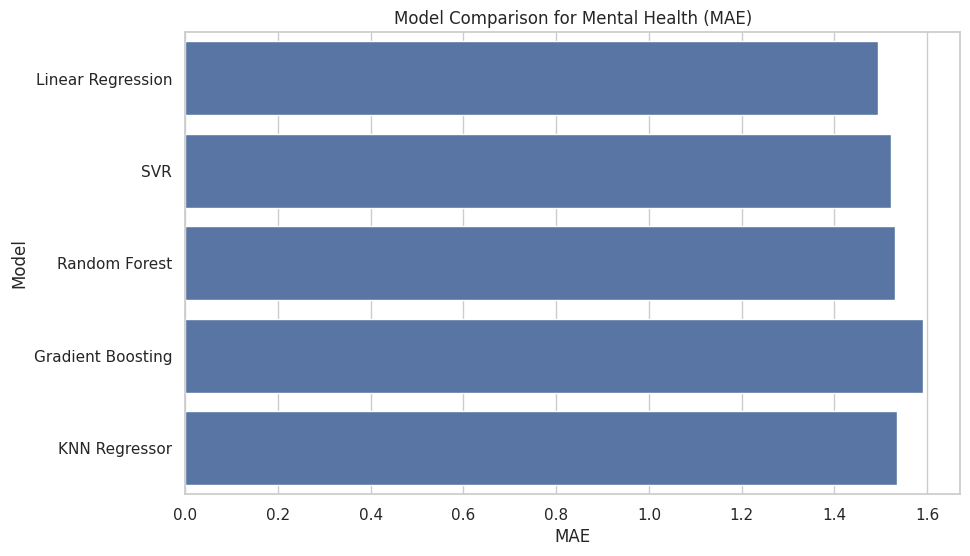

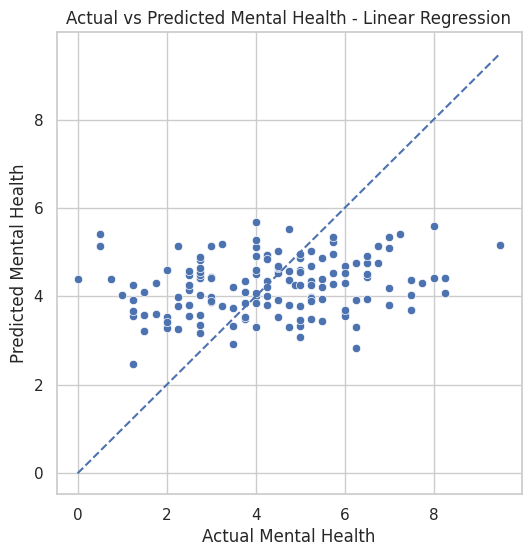

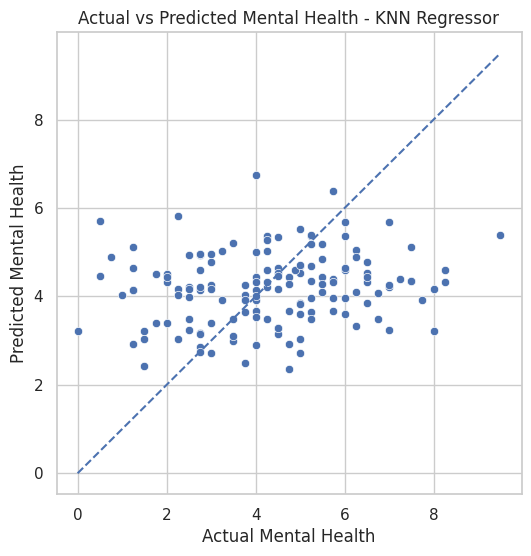

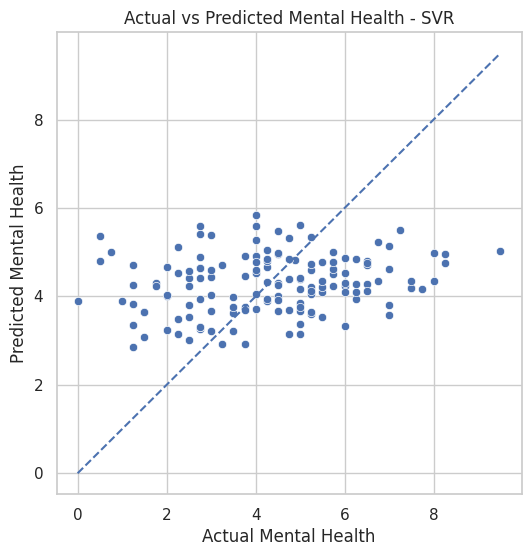

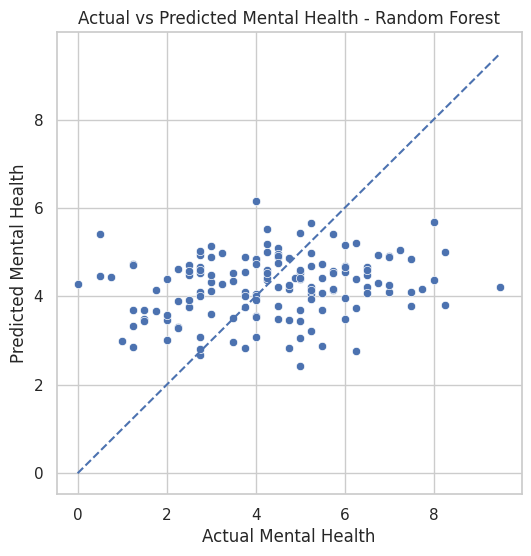

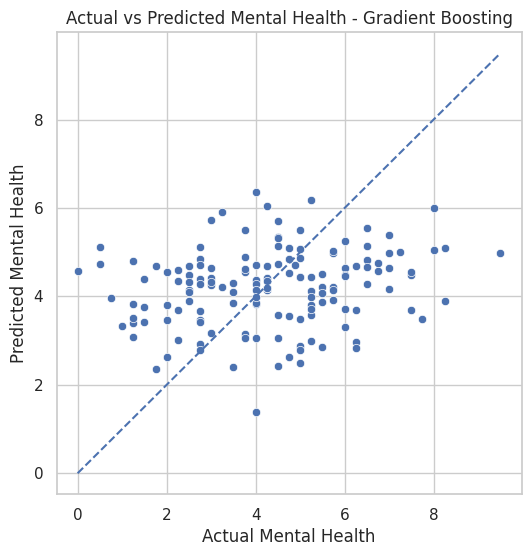


===== Top 15 Features: Random Forest =====
                         Feature  Importance
1                            BPM    0.132292
0                  Hours per day    0.106509
22  Frequency [Video game music]    0.054551
9                Frequency [EDM]    0.050960
20               Frequency [Rap]    0.047908
10              Frequency [Folk]    0.047549
17             Frequency [Metal]    0.045919
8            Frequency [Country]    0.044562
21              Frequency [Rock]    0.044107
7          Frequency [Classical]    0.041081
13              Frequency [Jazz]    0.040913
18               Frequency [Pop]    0.038037
19               Frequency [R&B]    0.038004
14             Frequency [K pop]    0.034224
12           Frequency [Hip hop]    0.033656


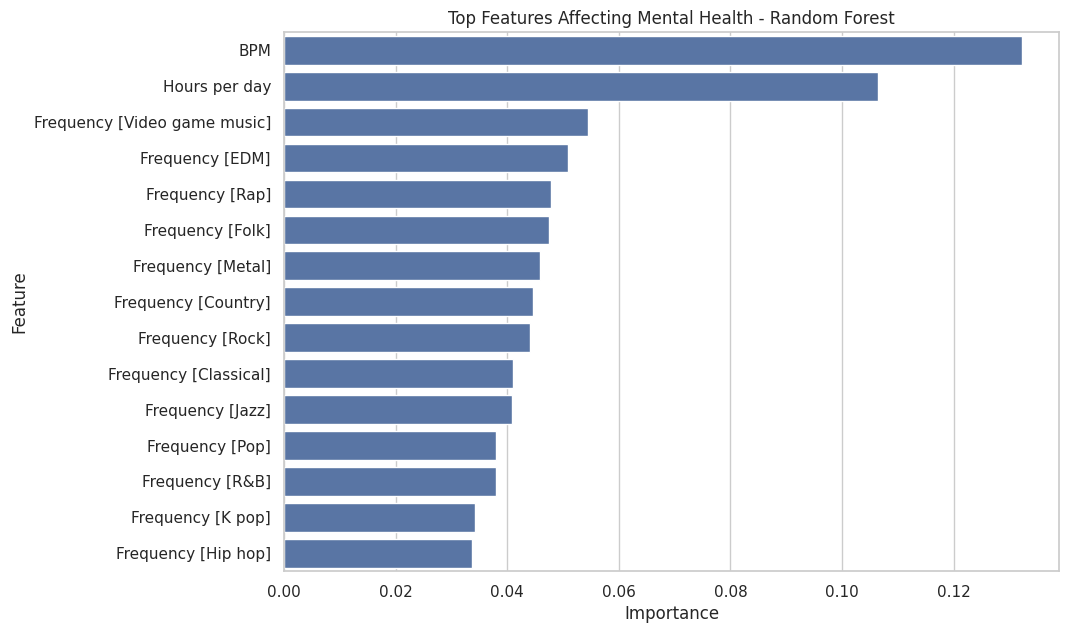


===== Top 15 Features: Gradient Boosting =====
                         Feature  Importance
1                            BPM    0.193806
0                  Hours per day    0.150373
10              Frequency [Folk]    0.060479
22  Frequency [Video game music]    0.057818
20               Frequency [Rap]    0.048583
21              Frequency [Rock]    0.046670
13              Frequency [Jazz]    0.046037
8            Frequency [Country]    0.046007
19               Frequency [R&B]    0.037997
14             Frequency [K pop]    0.036893
17             Frequency [Metal]    0.036278
9                Frequency [EDM]    0.036230
7          Frequency [Classical]    0.026067
15             Frequency [Latin]    0.024806
4                       Composer    0.021041


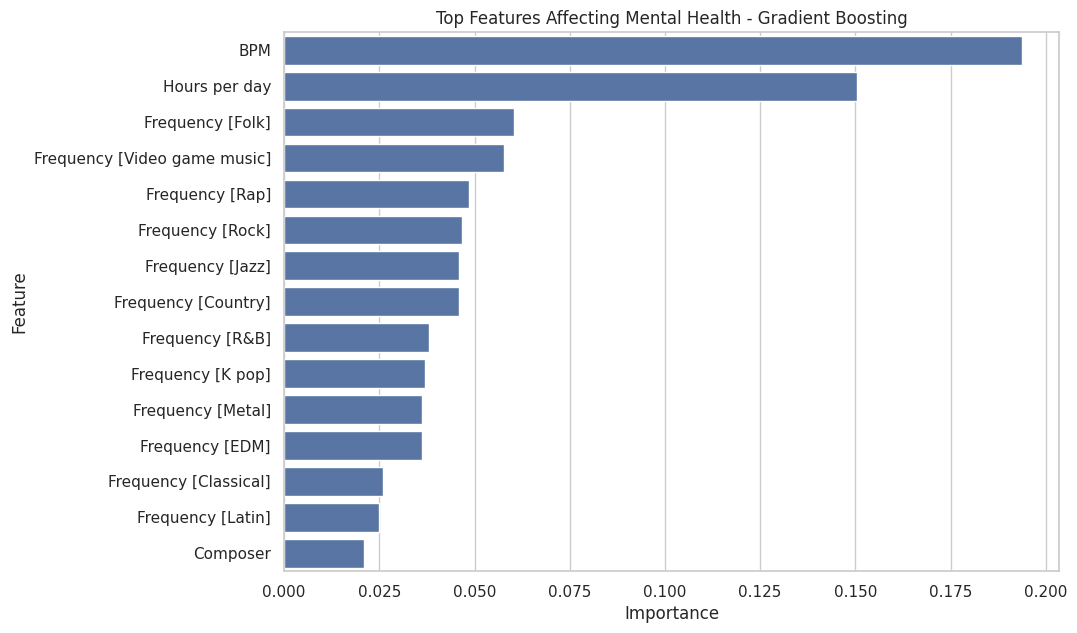


Top positive correlations with Mental Health:
Mental_Severity_All             1.000000
Anxiety                         0.757212
Depression                      0.749604
Insomnia                        0.685350
OCD                             0.620402
Hours per day                   0.158469
Frequency [Rock]                0.142934
Frequency [Metal]               0.125645
Frequency [Video game music]    0.114283
Frequency [EDM]                 0.108330
Name: Mental_Severity_All, dtype: float64

Top negative correlations with Mental Health:
BPM                        0.043793
Frequency [Jazz]           0.037305
Instrumentalist            0.030224
Frequency [Latin]          0.028337
Frequency [K pop]          0.020887
Frequency [Classical]      0.000099
Frequency [Country]       -0.014218
Frequency [Gospel]        -0.020952
Music effects_No effect   -0.099787
Age                       -0.156830
Name: Mental_Severity_All, dtype: float64

FINAL SUMMARY
Best model: Linear Regression
Best R²

In [73]:
sns.set_theme(style="whitegrid")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# Regression target
y = df["Mental_Severity_All"]


# ONLY music-related features
music_features = [
    "Hours per day",
    "BPM",
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages"
]

music_features = [col for col in music_features if col in df.columns]

frequency_cols = [col for col in df.columns if col.startswith("Frequency")]
genre_cols = [col for col in df.columns if col.startswith("Fav genre_")]
effects_cols = [col for col in df.columns if col.startswith("Music effects_")]

features = music_features + frequency_cols + genre_cols + effects_cols
features = [col for col in features if col in df.columns]

X = df[features]

print("\nNumber of selected features:", len(features))


# =========================
# Check leakage (UPDATED)
# =========================
leakage_cols = ["Age", "Depression", "Anxiety", "Insomnia", "OCD", "Mental_Severity_All"]

for col in leakage_cols:
    if col in X.columns:
        print("ERROR: Leakage column found in X ->", col)


#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


#models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=7))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1.0, epsilon=0.2))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# =========================
# Train + Evaluate
# =========================
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    predictions[name] = y_pred

    print(f"\n===== {name} =====")
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2  :", round(r2, 3))


#results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n==============================")
print("MODEL COMPARISON RESULTS (MENTAL HEALTH)")
print("==============================")
print(results_df)


#bar plots
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2", y="Model")
plt.title("Model Comparison for Mental Health (R²)")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="RMSE", y="Model")
plt.title("Model Comparison for Mental Health (RMSE)")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="MAE", y="Model")
plt.title("Model Comparison for Mental Health (MAE)")
plt.show()


#actual vs Predicted
for name, y_pred in predictions.items():
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel("Actual Mental Health")
    plt.ylabel("Predicted Mental Health")
    plt.title(f"Actual vs Predicted Mental Health - {name}")

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.show()


#feature importance
tree_models = {
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"]
}

for name, model in tree_models.items():
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"\n===== Top 15 Features: {name} =====")
    print(importance_df.head(15))

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df.head(15),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top Features Affecting Mental Health - {name}")
    plt.show()


#correlation
corr_with_target = df.corr(numeric_only=True)["Mental_Severity_All"].sort_values(ascending=False)

print("\nTop positive correlations with Mental Health:")
print(corr_with_target.head(10))

print("\nTop negative correlations with Mental Health:")
print(corr_with_target.tail(10))


#final summary
best_model = results_df.iloc[0]["Model"]
best_r2 = results_df.iloc[0]["R2"]

print("\n==============================")
print("FINAL SUMMARY")
print("==============================")
print(f"Best model: {best_model}")
print(f"Best R²: {best_r2:.3f}")
print("Analysis complete.")

Among the models tested, Linear Regression performed the best (R² ≈ 0.034), followed closely by SVR (R² ≈ 0.030). Random Forest performed slightly worse (R² ≈ 0.013), while Gradient Boosting and KNN had negative R² values, indicating very poor predictions.

Overall, all models achieved very low R² scores. This suggests that music-related features alone are not strong predictors of a person’s overall mental health level.

#Which music-related features are associated with overall mental health severity?

A composite score defining severity (mental health) was produced through four variables (depression, anxiety, insomnia, and OCD).

Different weights could be given to each part, but to choose the right weights, we would need outside knowledge. But this dataset does not provide that information, all variables were treated the same. This makes the results easier to understand and the calculation simpler.

The research studies the relationship between music and mental health using two methods: predicting depression and predicting a combined score for overall mental severity (by combining four variables).

The results show that music-related features have very low ability to predict either type of outcome. The model was slightly more accurate when predicting depression (R² ≈ 0.046) than when predicting overall mental health (R² ≈ 0.013).

Music shows some small relationship with specific aspects of mental health (such as depression), but these relationships do not apply to overall mental health. The combined score used in this research may reduce some useful patterns, since different mental health variables represent different aspects.

The results suggest that music listening behavior may be related to emotional patterns, but it is not a strong predictor of mental health by itself.

---

After talking with Jake, I added Support Vector Machine (SVM) as an additional classification model and Support Vector Regression (SVR) as an additional regression model. SVM was included because it is effective for high-dimensional datasets and can model non-linear decision boundaries using kernels. Since the dataset contains many encoded music-related features, SVM provides a useful comparison with Logistic Regression and Random Forest.